In [55]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
import operator

In [56]:

load_dotenv("../../../LangChainModels/.env") # Load environment variables from .env file

True

In [57]:
class State(TypedDict):
    review : str
    sentiment: Literal["positive", "negative", "neutral"]
    diagnostic: dict
    response: str


In [58]:
llm = ChatOpenAI()

In [59]:
class Sentiment(BaseModel):
    sentiment: Literal["positive", "negative", 'neutral'] = Field(..., description="The sentiment of the review")

In [60]:
structured_llm = llm.with_structured_output(Sentiment)

d:\pythonProj\python-for-ai\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:2682: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [61]:
class Diagnostic(BaseModel):
    tone: Literal[
        "calm",
        "frustrated",
        "angry",
        "disappointed",
        "confused",
        'other'
    ]

    issue_type: Literal[
        "delivery",
        "product",
        "payment",
        "refund",
        "customer_service",
        "technical",
        "other"
    ]

    urgency: Literal[
        "low",
        "medium",
        "high"
    ]

In [62]:
structured_diagnostic_llm = llm.with_structured_output(Diagnostic)

In [63]:
def find_sentiment(state: State):
    review = state['review']
    sentiment = structured_llm.invoke(f'Extract the sentiment of this review and classify it as either positive or negative or neutral: {review}')
    state['sentiment'] = sentiment
    return state

In [64]:
def run_diagnostic(state: State):
    review = state['review']
    sentiment = state['sentiment']
    if sentiment == 'negative' or sentiment == 'neutral':
        diagnostic = structured_diagnostic_llm.invoke(f'Analyze the following review and provide a diagnostic report including tone, issue type, and urgency: {review}')
        state['diagnostic'] = diagnostic.model_dump()
    return state

In [65]:
def negative_response(state: State):
    review = state['review']
    diagnostic = state['diagnostic']
    response = llm.invoke(f'Given the following review: "{review}" and the diagnostic report: {diagnostic}, generate a professional and empathetic response to address the customer\'s concerns.')
    state['response'] = response
    return state

In [66]:
def neutral_response(state: State):
    review = state['review']
    response = llm.invoke(f'Given the following review: "{review}", generate a professional and empathetic response to address the customer\'s concerns.')
    state['response'] = response
    return state

In [67]:
def decide_sentiment(state: State):
    sentiment = state['sentiment']
    if sentiment == 'negative' or sentiment == 'neutral':
        return "run_diagnostic"
    else :
        return "positive_response"

In [68]:
def decide_response(state: State):
    sentiment = state['sentiment']
    if sentiment == 'neutral':
        return "neutral_response"
    else:
        return "negative_response"

In [69]:
def positive_response(state: State):
    review = state['review']
    response = llm.invoke(f'Given the following review: "{review}", generate a professional and appreciative response to thank the customer for their feedback.')
    state['response'] = response
    return state

In [70]:
graph = StateGraph(State)

In [71]:
#add nodes
graph.add_node("find_sentiment", find_sentiment)
graph.add_node("run_diagnostic", run_diagnostic)
graph.add_node("positive_response", positive_response)
graph.add_node("neutral_response", neutral_response)
graph.add_node("negative_response", negative_response)

In [72]:
#add edges
graph.add_edge(START, "find_sentiment")
graph.add_conditional_edges("find_sentiment", decide_sentiment, { "positive_response": "positive_response", "run_diagnostic": "run_diagnostic" })
graph.add_conditional_edges("run_diagnostic", decide_response, { "neutral_response": "neutral_response", "negative_response": "negative_response" })
graph.add_edge("positive_response", END)
graph.add_edge("neutral_response", END)
graph.add_edge("negative_response", END)

In [73]:
app = graph.compile()

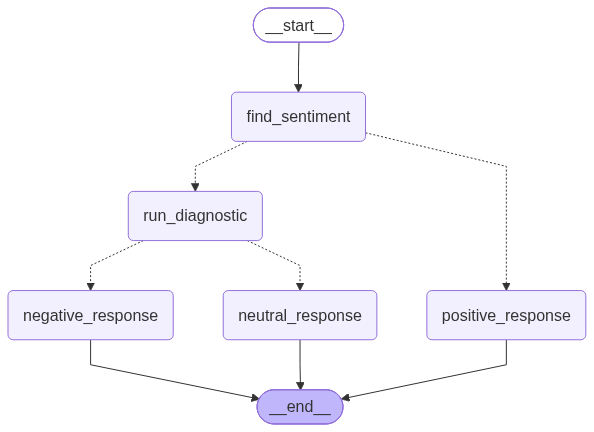

In [74]:
Image(app.get_graph().draw_mermaid_png())

In [75]:
user_input = input("Enter a customer review: ")

In [76]:
result = app.invoke({
    "review": user_input,
    "sentiment": "",
    "response": ""
})
print(result['sentiment'])
print(result["response"])

sentiment='neutral'
content='Dear [Customer],\n\nThank you for taking the time to share your feedback with us. We are pleased to hear that you received the headphones earlier than expected and that you were satisfied with the packaging. We appreciate your detailed analysis of the sound quality and your experience using the product outdoors.\n\nWe apologize for the inconvenience you have experienced with the left earbud occasionally disconnecting. We are glad to know that our customer support team was able to provide assistance and that the resetting of the device helped for a while. We take your feedback seriously and will continue to work towards improving the product to ensure a consistent and reliable experience for our customers.\n\nThank you for your continued support and understanding. If you have any further concerns or feedback, please do not hesitate to reach out to us. We value your input and strive to provide the best possible experience for all our customers.\n\nBest regard